# Unión de fuentes y análisis exploratorio

Juntamos las 10 tablas ya limpias (`DF_*_LIMPIO.csv` de buscametas, xipgroc, carreirasgalegas, ccnorte, cronofinisher, mychip, sportmaniacs, cursescat, iter5 y cruzandolameta) en una sola tabla, quedándonos solo con las 12 columnas que comparten todas las fuentes: `fuente`, `nombre_carrera`, `fecha`, `dia_semana`, `distancia`, `tipo_modalidad`, `publico`, `finisher_d`, `finisher_h`, `municipio`, `comarca` y `provincia`. Las columnas propias de cada fuente se quedan fuera porque no son comparables entre unas y otras.

In [1]:
from pathlib import Path
import pandas as pd
import re

FUENTES = {
    "buscametas": r"../../data/processed/buscametas/DF_BUSCAMETAS_LIMPIO.csv",
    "championsxip": r"../../data/processed/championsxip/DF_CHAMPIONSXIP_LIMPIO.csv",
    "carreirasgalegas": r"../../data/processed/carreirasgalegas/DF_CARREIRASGALEGAS_LIMPIO.csv",
    "ccnorte": r"../../data/processed/ccnorte/DF_CCNORTE_LIMPIO.csv",
    "cronofinisher": r"../../data/processed/cronofinisher/DF_CRONOFINISHER_LIMPIO.csv",
    "mychip": r"../../data/processed/mychip/DF_MYCHIP_LIMPIO.csv",
    "sportmaniacs": r"../../data/processed/sportmaniacs/DF_SPORTMANIACS_LIMPIO.csv",
    "cursescat": r"../../data/processed/cursescat/DF_CURSESCAT_LIMPIO.csv",
    "iter5": r"../../data/processed/iter5/DF_ITER5_LIMPIO.csv",
    "cruzandolameta": r"../../data/processed/cruzandolameta/DF_CRUZANDOLAMETA_LIMPIO.csv",
}

COMUNES = [
    "fuente", "nombre_carrera", "fecha", "dia_semana", "distancia", "tipo_modalidad",
    "publico", "finisher_d", "finisher_h", "municipio", "comarca", "provincia",
]

tablas = []
for nombre, ruta in FUENTES.items():
    df = pd.read_csv(ruta, encoding="utf-8-sig")[COMUNES]
    assert (df["fuente"] == nombre).all(), f"'{nombre}': hay filas con 'fuente' distinto, revisar columnas"
    print(f"{nombre}: {len(df)} filas")
    tablas.append(df)

todas = pd.concat(tablas, ignore_index=True)
todas["fecha"] = pd.to_datetime(todas["fecha"])

print()
print("Total filas:", len(todas))
todas.head()

buscametas: 314 filas
xipgroc: 2632 filas
carreirasgalegas: 2797 filas
ccnorte: 6280 filas


cronofinisher: 1295 filas
mychip: 4751 filas
sportmaniacs: 20844 filas
cursescat: 469 filas
iter5: 1834 filas


cruzandolameta: 1692 filas

Total filas: 42908


,fuente,nombre_carrera,fecha,dia_semana,distancia,tipo_modalidad,publico,finisher_d,finisher_h,municipio,comarca,provincia
0,buscametas,Areta Trail Lasterketa,2026-07-25,Sábado,0.0,trail running,Absoluta/General,17,147,Areta,NaN,Álava
1,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,0.0,Ciclismo y btt,Absoluta/General,0,30,Ezcaray,NaN,La Rioja
2,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,93.0,Ciclismo y btt,Absoluta/General,2,38,Ezcaray,NaN,La Rioja
3,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,57.0,Ciclismo y btt,Absoluta/General,2,31,Ezcaray,NaN,La Rioja
4,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,42.0,Ciclismo y btt,Absoluta/General,2,10,Ezcaray,NaN,La Rioja


In [2]:
# Un mismo evento puede haber sido capturado por más de una fuente (p.ej.
# una carrera popular que sale tanto en sportmaniacs como en cronofinisher)
# — sin quitar esto, esas carreras se cuentan dos veces. Detectamos
# duplicados por nombre normalizado (sin acentos/mayúsculas/puntuación,
# para no fallar por "1ª" vs "I" o tildes) + fecha exacta. Cuando el mismo
# evento aparece en varias fuentes, nos quedamos solo con la fuente que
# tiene más finishers sumados para ese evento — normalmente porque la otra
# fuente solo registró el evento sin resultados (filas en 0) o con menos
# categorías capturadas.
import unicodedata


def _normalizar_nombre(texto):
    if pd.isna(texto):
        return None
    t = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode("ascii").upper()
    return re.sub(r"[^A-Z0-9]+", " ", t).strip()


todas["_nombre_norm"] = todas["nombre_carrera"].apply(_normalizar_nombre)
todas["_total_tmp"] = todas["finisher_d"] + todas["finisher_h"]

resumen = todas.groupby(["_nombre_norm", "fecha", "fuente"])["_total_tmp"].sum().reset_index()
n_fuentes = resumen.groupby(["_nombre_norm", "fecha"])["fuente"].transform("nunique")
resumen_dup = resumen[n_fuentes > 1]

idx_ganador = resumen_dup.groupby(["_nombre_norm", "fecha"])["_total_tmp"].idxmax()
ganador = resumen_dup.loc[idx_ganador, ["_nombre_norm", "fecha", "fuente"]].rename(
    columns={"fuente": "_fuente_ganadora"}
)

antes = len(todas)
todas = todas.merge(ganador, on=["_nombre_norm", "fecha"], how="left")
es_evento_duplicado = todas["_fuente_ganadora"].notna()
filas_a_quitar = es_evento_duplicado & (todas["fuente"] != todas["_fuente_ganadora"])

print(f"Eventos duplicados entre fuentes: {ganador.shape[0]}")
print(f"Filas eliminadas (de la fuente no ganadora): {filas_a_quitar.sum()}")
print(f"  - con 0 finishers (fuente que no llegó a capturar resultados): "
      f"{(filas_a_quitar & (todas['_total_tmp'] == 0)).sum()}")
print(f"  - con datos, pero menos completos que la fuente ganadora: "
      f"{(filas_a_quitar & (todas['_total_tmp'] > 0)).sum()}")
print()
print("Filas eliminadas, por fuente:")
print(todas.loc[filas_a_quitar, "fuente"].value_counts())

todas = todas.loc[~filas_a_quitar].drop(columns=["_nombre_norm", "_total_tmp", "_fuente_ganadora"])
print()
print(f"Total filas: {antes} -> {len(todas)}")

Eventos duplicados entre fuentes: 29
Filas eliminadas (de la fuente no ganadora): 65
  - con 0 finishers (fuente que no llegó a capturar resultados): 37
  - con datos, pero menos completos que la fuente ganadora: 28

Filas eliminadas, por fuente:
fuente
cronofinisher     25
mychip            25
cruzandolameta    10
sportmaniacs       3
ccnorte            2
Name: count, dtype: int64

Total filas: 42908 -> 42843


In [3]:
# Además de eventos repetidos entre fuentes, hay filas totalmente
# idénticas dentro de una misma fuente (mismo evento, categoría y hasta el
# mismo número de finishers) — repartidas entre 7 fuentes distintas sin
# que ninguna concentre la mayoría, así que parece un artefacto general de
# scraping (páginas o categorías leídas dos veces) y no un fallo de una
# fuente en concreto. Al ser copias exactas, quedarnos con una sola no
# pierde ninguna información real.
cols_evento = [
    "fuente", "nombre_carrera", "fecha", "distancia", "tipo_modalidad", "publico",
    "finisher_d", "finisher_h",
]
antes = len(todas)
print("Filas idénticas dentro de la misma fuente, por fuente:")
print(todas.loc[todas.duplicated(subset=cols_evento, keep=False), "fuente"].value_counts())

todas = todas.drop_duplicates(subset=cols_evento).reset_index(drop=True)
print()
print(f"Total filas: {antes} -> {len(todas)}")

Filas idénticas dentro de la misma fuente, por fuente:
fuente
cronofinisher     637
sportmaniacs      547
ccnorte           433
mychip            313
xipgroc            78
cruzandolameta      8
buscametas          2
Name: count, dtype: int64

Total filas: 42843 -> 41650


In [4]:
# cronofinisher (79% de sus filas) y carreirasgalegas (66%) tienen una
# proporción de filas en 0/0 mucho más alta que el resto de fuentes, y no
# se explica por categorías especiales (pasa igual en Absoluta/General) ni
# solo por carreras que aún no se han disputado (hay filas en 0 desde
# 2015/2019) — son categorías que existieron pero de las que nunca se
# llegó a capturar el resultado real. Las marcamos como NaN, no 0, igual
# que ya se hace con el centinela de "distancia" — así no se cuentan como
# "carrera real de 0 personas" ni en las estadísticas ni en un futuro modelo.
_FUENTES_SIN_RESULTADOS = ["cronofinisher", "carreirasgalegas"]
_sin_resultados = (
    todas["fuente"].isin(_FUENTES_SIN_RESULTADOS)
    & (todas["finisher_d"] == 0)
    & (todas["finisher_h"] == 0)
)

print(f"Filas marcadas como sin resultados (antes 0/0): {_sin_resultados.sum()}")
print(todas.loc[_sin_resultados, "fuente"].value_counts())

todas["finisher_d"] = todas["finisher_d"].astype("float64")
todas["finisher_h"] = todas["finisher_h"].astype("float64")
todas.loc[_sin_resultados, ["finisher_d", "finisher_h"]] = float("nan")

Filas marcadas como sin resultados (antes 0/0): 2474
fuente
carreirasgalegas    1858
cronofinisher        616
Name: count, dtype: int64


In [5]:
# carreirasgalegas ya fusiona "Cadete/Juvenil" dentro de "Infantil" en su
# propia limpieza (para esa fuente no hay más desglose que ese), así que
# para que "Infantil" signifique lo mismo en las 10 fuentes hacemos la
# misma fusión aquí, a nivel de toda la tabla.
antes = todas["publico"].value_counts()
todas["publico"] = todas["publico"].replace("Cadete/Juvenil", "Infantil")
print("publico antes de fusionar Cadete/Juvenil -> Infantil:")
print(antes)
print()
print("publico después:")
print(todas["publico"].value_counts())

publico antes de fusionar Cadete/Juvenil -> Infantil:
publico
Absoluta/General     30154
Infantil              7552
Cadete/Juvenil        2021
Otros                  590
Mayores/Veteranos      518
Equipos                492
Elite                  323
Name: count, dtype: int64

publico después:
publico
Absoluta/General     30154
Infantil              9573
Otros                  590
Mayores/Veteranos      518
Equipos                492
Elite                  323
Name: count, dtype: int64


In [6]:
# distancia / municipio / comarca / provincia pueden venir vacíos según la
# fuente; finisher_d/finisher_h también, pero solo en cronofinisher y
# carreirasgalegas (las filas sin resultados reales que acabamos de marcar
# como NaN) -- el resto de columnas no debería tener ningún nulo.
print("Filas por fuente:")
print(todas["fuente"].value_counts())
print()

print("Nulos por columna:")
print(todas.isna().sum())
print()

print("Rango de fechas:", todas["fecha"].min(), "->", todas["fecha"].max())

Filas por fuente:
fuente
sportmaniacs        20500
ccnorte              6023
mychip               4563
carreirasgalegas     2797
xipgroc              2592
iter5                1834
cruzandolameta       1678
cronofinisher         881
cursescat             469
buscametas            313
Name: count, dtype: int64

Nulos por columna:
fuente                0
nombre_carrera        0
fecha                 0
dia_semana            0
distancia             0
tipo_modalidad        0
publico               0
finisher_d         2474
finisher_h         2474
municipio          2126
comarca           20375
provincia          2350
dtype: int64

Rango de fechas: 2003-11-16 00:00:00 -> 2026-08-15 00:00:00


In [7]:
SALIDA = Path("../../data/processed/union/DF_TODAS.csv")
todas.to_csv(SALIDA, index=False, encoding="utf-8-sig")
print("Guardado en", SALIDA)

Guardado en C:\Users\Clàudia Rafart\OneDrive - Prenomics\Escritorio\Altres\analisis_data\DF_TODAS.csv


## Variables derivadas y cruce con población

Antes de meternos en el análisis añadimos las columnas que vamos a necesitar todo el rato: año, mes y estación a partir de la fecha, el total de finishers por fila, si la carrera es de fin de semana, y la población del municipio (cruzando con el nomenclátor del INE, datos de 2025). Así las tenemos ya listas como variables numéricas para el univariable, la correlación y el cruce con los objetivos.

In [8]:
MES_A_ESTACION = {
    12: "Invierno", 1: "Invierno", 2: "Invierno",
    3: "Primavera", 4: "Primavera", 5: "Primavera",
    6: "Verano", 7: "Verano", 8: "Verano",
    9: "Otoño", 10: "Otoño", 11: "Otoño",
}

todas["anyo"] = todas["fecha"].dt.year
todas["mes"] = todas["fecha"].dt.month
todas["estacion"] = todas["mes"].map(MES_A_ESTACION)
todas["total_finishers"] = todas["finisher_d"] + todas["finisher_h"]
todas["es_finde"] = todas["dia_semana"].isin(["Sábado", "Domingo"])

todas[["fecha", "anyo", "mes", "estacion", "total_finishers", "es_finde"]].head()

,fecha,anyo,mes,estacion,total_finishers,es_finde
0,2026-07-25,2026,7,Verano,164.0,True
1,2026-07-25,2026,7,Verano,30.0,True
2,2026-07-25,2026,7,Verano,40.0,True
3,2026-07-25,2026,7,Verano,33.0,True
4,2026-07-25,2026,7,Verano,12.0,True


In [9]:
import glob
import unicodedata

def normalizar(texto):
    """Mayúsculas y sin acentos, para poder cruzar texto libre con el nomenclátor del INE."""
    if pd.isna(texto):
        return None
    texto = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode("ascii")
    return texto.upper().strip()

# Las comunidades multiprovinciales (Galicia, Catalunya, Andalucía, la
# Comunidad Valenciana, Castilla y León, Castilla-La Mancha, Aragón) no se
# pueden asignar a una sola provincia del INE, así que quedan sin cruzar.
PROVINCIA_INE = {
    1: ["Álava", "Araba", "Araba/Álava"], 2: ["Albacete"], 3: ["Alicante", "Alacant"],
    4: ["Almería"], 5: ["Ávila"], 6: ["Badajoz"], 7: ["Baleares", "Illes Balears", "Baleares (Illes)"],
    8: ["Barcelona"], 9: ["Burgos"], 10: ["Cáceres"], 11: ["Cádiz"], 12: ["Castellón", "Castelló"],
    13: ["Ciudad Real"], 14: ["Córdoba"], 15: ["La Coruña", "A Coruña"], 16: ["Cuenca"],
    17: ["Girona", "Gerona"], 18: ["Granada"], 19: ["Guadalajara"], 20: ["Guipúzcoa", "Gipuzkoa"],
    21: ["Huelva"], 22: ["Huesca"], 23: ["Jaén"], 24: ["León"], 25: ["Lleida", "Lérida"],
    26: ["La Rioja"], 27: ["Lugo"], 28: ["Madrid", "Comunidad de Madrid"], 29: ["Málaga"],
    30: ["Murcia", "Región de Murcia"], 31: ["Navarra"], 32: ["Ourense", "Orense"],
    33: ["Asturias", "Asturias / Asturies"], 34: ["Palencia"], 35: ["Las Palmas"],
    36: ["Pontevedra"], 37: ["Salamanca"], 38: ["Santa Cruz de Tenerife"], 39: ["Cantabria"],
    40: ["Segovia"], 41: ["Sevilla"], 42: ["Soria"], 43: ["Tarragona"], 44: ["Teruel"],
    45: ["Toledo"], 46: ["Valencia", "València"], 47: ["Valladolid"], 48: ["Vizcaya", "Bizkaia"],
    49: ["Zamora"], 50: ["Zaragoza"], 51: ["Ceuta"], 52: ["Melilla"],
}
PROVINCIA_A_CODIGO = {normalizar(n): c for c, ns in PROVINCIA_INE.items() for n in ns}

INE_DIR = Path("../../data/processed/union")
INE_PATH = glob.glob(str(INE_DIR / "DF_INE_Poblaciones_*.xlsx"))[0]
ine = pd.read_excel(INE_PATH, sheet_name="Sexo")

# "Unidad Poblacional" son 6 cifras de código (entidad + núcleo) seguidas
# del nombre. El código "000000" es el total del municipio, que es la
# única fila que nos interesa aquí (descartamos pedanías y núcleos sueltos).
ine["_codigo"] = ine["Unidad Poblacional"].str.slice(0, 6)
ine_municipios = ine[ine["_codigo"] == "000000"].copy()
ine_municipios["municipio_norm"] = ine_municipios["Unidad Poblacional"].str.slice(6).str.strip().apply(normalizar)
ine_municipios["provincia_ine"] = ine_municipios["Provincia"].astype(int)
ine_municipios = ine_municipios.rename(columns={
    "Total 2025": "poblacion_total", "Hombres 2025": "poblacion_hombres", "Mujeres 2025": "poblacion_mujeres",
})[["municipio_norm", "provincia_ine", "poblacion_total", "poblacion_hombres", "poblacion_mujeres"]]
ine_municipios = ine_municipios.drop_duplicates(subset=["municipio_norm", "provincia_ine"], keep="first")

todas["municipio_norm"] = todas["municipio"].apply(normalizar)
todas["provincia_ine"] = todas["provincia"].apply(normalizar).map(PROVINCIA_A_CODIGO)
todas = todas.merge(ine_municipios, on=["municipio_norm", "provincia_ine"], how="left")

cobertura = 100 * todas["poblacion_total"].notna().mean()
print(f"Filas con población cruzada: {todas['poblacion_total'].notna().sum()} de {len(todas)} ({cobertura:.1f}%)")

Filas con población cruzada: 30609 de 41650 (73.5%)


In [10]:
print("Cobertura del cruce con el INE por fuente (% de filas con población encontrada):")
print(todas.groupby("fuente")["poblacion_total"].apply(lambda s: round(100 * s.notna().mean(), 1)))
print()

print("Valores de 'provincia' sin equivalente en el INE (top 10, casi todos son comunidades autónomas):")
print(todas.loc[todas["provincia"].notna() & todas["provincia_ine"].isna(), "provincia"].value_counts().head(10))

Cobertura del cruce con el INE por fuente (% de filas con población encontrada):
fuente
buscametas          70.0
carreirasgalegas    70.0
ccnorte             28.2
cronofinisher       57.7
cruzandolameta      91.3
cursescat           84.6
iter5               70.2
mychip              52.4
sportmaniacs        92.6
xipgroc             63.1
Name: poblacion_total, dtype: float64

Valores de 'provincia' sin equivalente en el INE (top 10, casi todos son comunidades autónomas):
provincia
Galicia                 2596
Catalunya                531
Andalucía                392
Castilla-La Mancha       132
Comunitat Valenciana      77
Aragón                    56
València / Valencia       24
Alacant / Alicante        21
Castile-La Mancha         19
Castilla y León           13
Name: count, dtype: int64


La cobertura no llega ni al 65% en la mayoría de fuentes, y en mychip y carreirasgalegas apenas roza el 3-13%. El motivo principal no es un problema de nombres de municipio, sino que en esas fuentes la columna `provincia` guarda en realidad la comunidad autónoma (Galicia, Comunidad Valenciana, Catalunya...), y una comunidad con varias provincias no se puede asignar a un código INE sin más información. Para el resto de fuentes el problema es más de formato (dobles nombres oficiales, pedanías que no son municipio propio). A partir de aquí, cualquier cálculo con `poblacion_total` trabaja solo sobre ese subconjunto cruzado, no sobre la tabla entera.

## 1. Análisis univariable

Repasamos cada campo por separado antes de mirar relaciones entre variables.

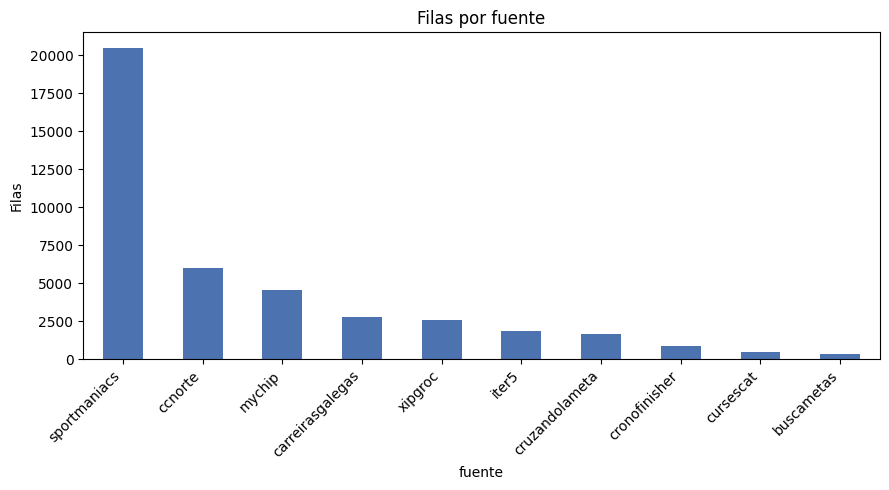

sportmaniacs concentra sola el 49% de las filas. El reparto entre fuentes es muy desigual, así que cualquier estadística global de aquí en adelante está bastante condicionada por esa fuente.


fuente
sportmaniacs        20500
ccnorte              6023
mychip               4563
carreirasgalegas     2797
xipgroc              2592
iter5                1834
cruzandolameta       1678
cronofinisher         881
cursescat             469
buscametas            313
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

conteo_fuente = todas["fuente"].value_counts()
conteo_fuente.plot(kind="bar", color="#4C72B0")
plt.title("Filas por fuente")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_fuente = conteo_fuente.index[0]
pct_top = 100 * conteo_fuente.iloc[0] / conteo_fuente.sum()
print(f"{top_fuente} concentra sola el {pct_top:.0f}% de las filas. El reparto entre fuentes es muy desigual, "
      "así que cualquier estadística global de aquí en adelante está bastante condicionada por esa fuente.")
conteo_fuente

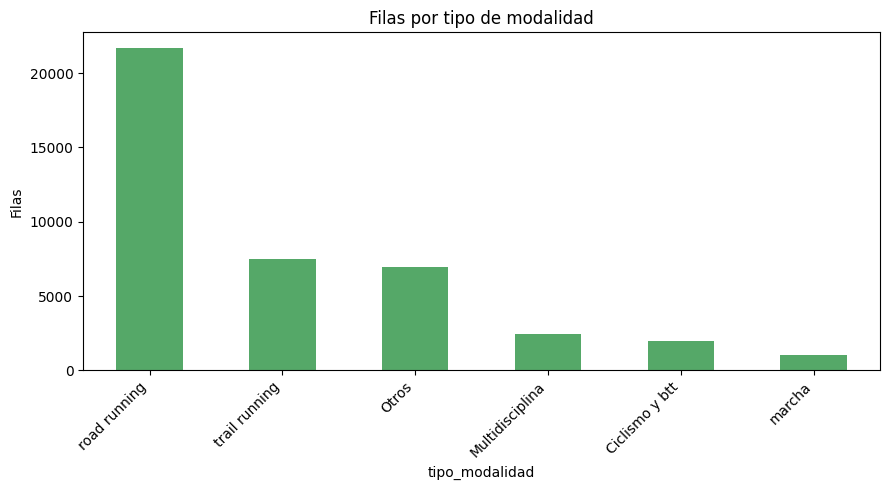

Entre road running y trail running suman el 70% de las filas; el resto de disciplinas (ciclismo, natación, multideporte...) son residuales en comparación.


tipo_modalidad
road running       21664
trail running       7506
Otros               6991
Multidisciplina     2422
Ciclismo y btt      2007
marcha              1060
Name: count, dtype: int64

In [12]:
conteo_tipo = todas["tipo_modalidad"].value_counts()
conteo_tipo.plot(kind="bar", color="#55A868")
plt.title("Filas por tipo de modalidad")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

pct_top2 = 100 * conteo_tipo.iloc[:2].sum() / conteo_tipo.sum()
print(f"Entre {conteo_tipo.index[0]} y {conteo_tipo.index[1]} suman el {pct_top2:.0f}% de las filas; "
      "el resto de disciplinas (ciclismo, natación, multideporte...) son residuales en comparación.")
conteo_tipo

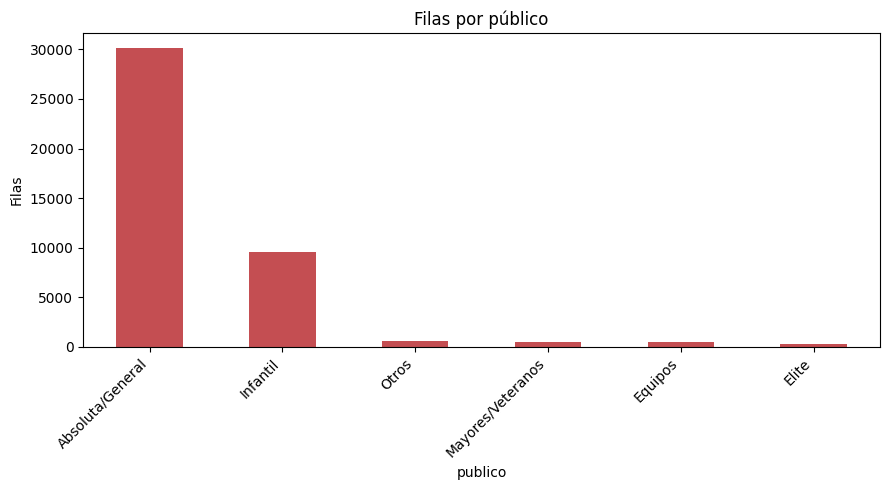

'Absoluta/General' es, con diferencia, la categoría más frecuente (30,154 filas). No es que apenas haya carreras infantiles o de categorías especiales: varias fuentes (cursescat, iter5, buena parte de sportmaniacs) simplemente no desglosan por edad y todo cae en esa categoría genérica.


publico
Absoluta/General     30154
Infantil              9573
Otros                  590
Mayores/Veteranos      518
Equipos                492
Elite                  323
Name: count, dtype: int64

In [13]:
conteo_publico = todas["publico"].value_counts()
conteo_publico.plot(kind="bar", color="#C44E52")
plt.title("Filas por público")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"'{conteo_publico.index[0]}' es, con diferencia, la categoría más frecuente ({conteo_publico.iloc[0]:,} filas). "
      "No es que apenas haya carreras infantiles o de categorías especiales: varias fuentes (cursescat, iter5, "
      "buena parte de sportmaniacs) simplemente no desglosan por edad y todo cae en esa categoría genérica.")
conteo_publico

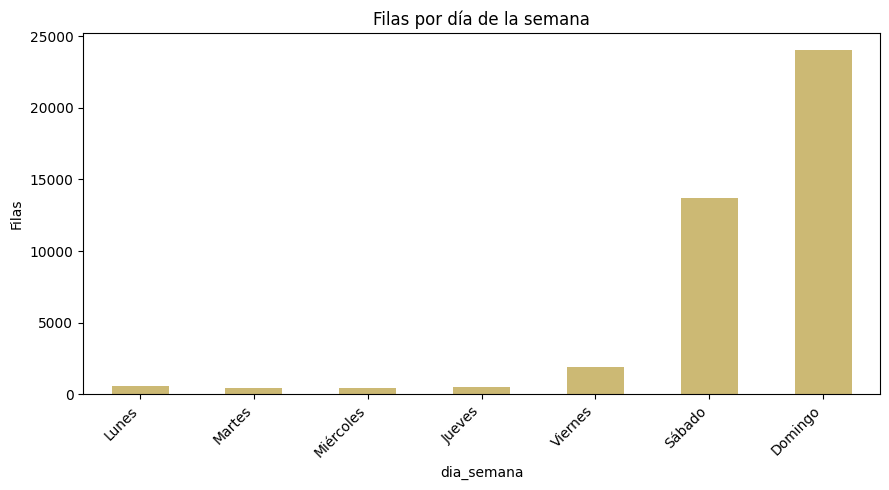

El 91% de las filas caen en sábado o domingo. Las carreras entre semana existen pero son la excepción, no la norma.


dia_semana
Lunes          584
Martes         461
Miércoles      452
Jueves         512
Viernes       1918
Sábado       13696
Domingo      24027
Name: count, dtype: int64

In [14]:
ORDEN_DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
por_dia = todas["dia_semana"].value_counts().reindex(ORDEN_DIAS)
por_dia.plot(kind="bar", color="#CCB974")
plt.title("Filas por día de la semana")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

pct_finde = 100 * por_dia[["Sábado", "Domingo"]].sum() / por_dia.sum()
print(f"El {pct_finde:.0f}% de las filas caen en sábado o domingo. Las carreras entre semana existen "
      "pero son la excepción, no la norma.")
por_dia

Distancia detectada en 20,073 filas de 41,650 (48%); el resto queda en 0 porque la fuente no la da (frecuente en categorías desglosadas solo por edad/género).
count    20073.000000
mean        14.759921
std         21.942026
min          0.001000
25%          5.000000
50%         10.000000
75%         17.000000
max        934.000000
Name: distancia, dtype: float64


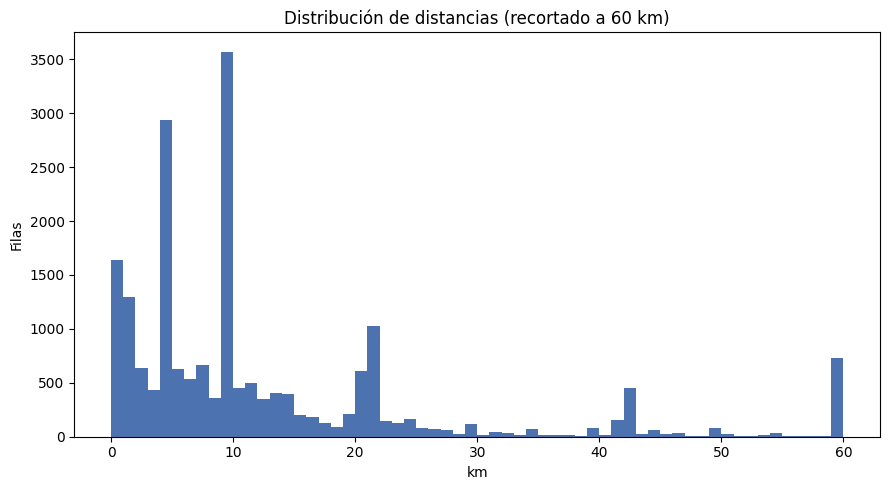

La mediana está en 10 km, con picos claros en las distancias de siempre (5, 10, 21, 42 km). Las distancias de ultra existen pero son cola, no quedan visibles en este recorte a 60 km.


In [15]:
con_distancia = todas.loc[todas["distancia"] != 0, "distancia"]
print(f"Distancia detectada en {len(con_distancia):,} filas de {len(todas):,} "
      f"({100 * len(con_distancia) / len(todas):.0f}%); el resto queda en 0 porque la fuente no la da "
      "(frecuente en categorías desglosadas solo por edad/género).")
print(con_distancia.describe())

con_distancia.clip(upper=60).plot(kind="hist", bins=60, color="#4C72B0")
plt.title("Distribución de distancias (recortado a 60 km)")
plt.xlabel("km")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

mediana = con_distancia.median()
print(f"La mediana está en {mediana:.0f} km, con picos claros en las distancias de siempre (5, 10, 21, 42 km). "
      "Las distancias de ultra existen pero son cola, no quedan visibles en este recorte a 60 km.")

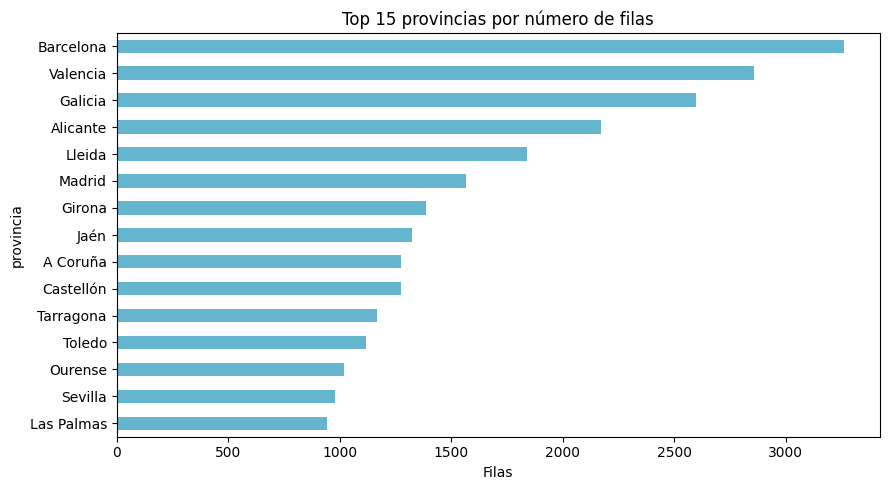

Barcelona encabeza el ranking con 3,260 filas. Esto dice más sobre qué fuentes hemos scrapeado (carreirasgalegas, buscametas y cursescat son monorregionales) que sobre dónde se corre más en España en términos absolutos.


In [16]:
top_provincias = todas["provincia"].value_counts().head(15)
top_provincias.sort_values().plot(kind="barh", color="#64B5CD")
plt.title("Top 15 provincias por número de filas")
plt.xlabel("Filas")
plt.tight_layout()
plt.show()

print(f"{top_provincias.index[0]} encabeza el ranking con {top_provincias.iloc[0]:,} filas. Esto dice más sobre "
      "qué fuentes hemos scrapeado (carreirasgalegas, buscametas y cursescat son monorregionales) que sobre "
      "dónde se corre más en España en términos absolutos.")

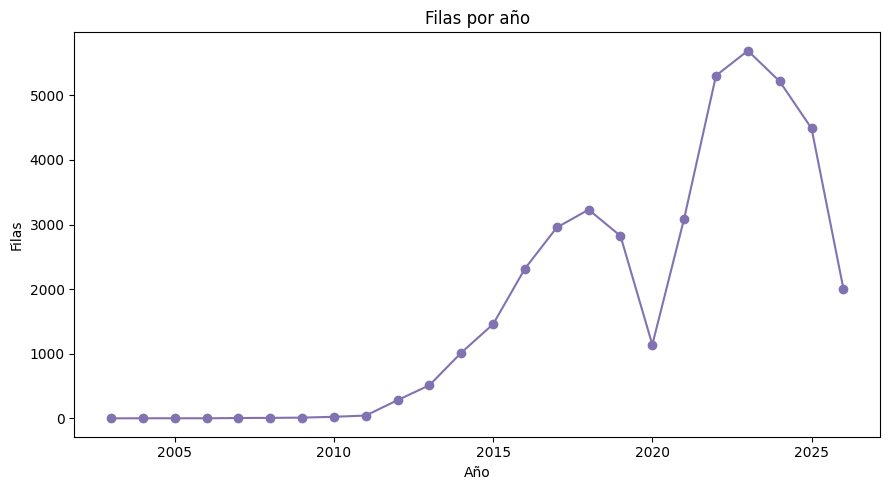

El pico está en 2023, con 5,691 filas. Los años en los extremos (muy antiguos o ya en 2026-2027) tienen pocas filas porque son eventos sueltos o carreras futuras ya programadas, no una caída real de actividad.


In [17]:
por_anyo = todas.groupby("anyo").size()
por_anyo.plot(kind="line", marker="o", color="#8172B2")
plt.title("Filas por año")
plt.ylabel("Filas")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

anyo_max = por_anyo.idxmax()
print(f"El pico está en {anyo_max}, con {por_anyo.max():,} filas. Los años en los extremos (muy antiguos o "
      "ya en 2026-2027) tienen pocas filas porque son eventos sueltos o carreras futuras ya programadas, "
      "no una caída real de actividad.")

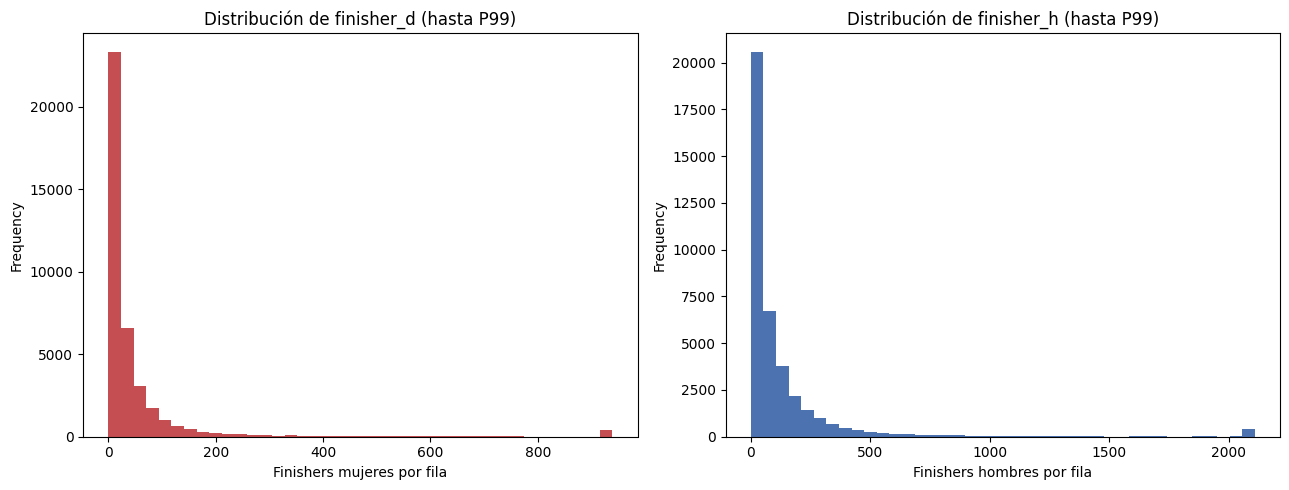

         finisher_d    finisher_h
count  39176.000000  39176.000000
mean      70.352639    146.969063
std      512.027320    469.216452
min        0.000000      0.000000
25%        3.000000     11.000000
50%       16.000000     47.000000
75%       44.000000    131.000000
max    30597.000000  23059.000000

Las dos variables objetivo están muy sesgadas a la derecha: la mediana de finisher_h (47) casi duplica la de finisher_d (16), y ambas tienen una cola larga de carreras con cientos o miles de finishers.


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

todas["finisher_d"].clip(upper=todas["finisher_d"].quantile(0.99)).plot(kind="hist", bins=40, ax=ax1, color="#C44E52")
ax1.set_title("Distribución de finisher_d (hasta P99)")
ax1.set_xlabel("Finishers mujeres por fila")

todas["finisher_h"].clip(upper=todas["finisher_h"].quantile(0.99)).plot(kind="hist", bins=40, ax=ax2, color="#4C72B0")
ax2.set_title("Distribución de finisher_h (hasta P99)")
ax2.set_xlabel("Finishers hombres por fila")

plt.tight_layout()
plt.show()

print(todas[["finisher_d", "finisher_h"]].describe())
print()
print(f"Las dos variables objetivo están muy sesgadas a la derecha: la mediana de finisher_h "
      f"({todas['finisher_h'].median():.0f}) casi duplica la de finisher_d ({todas['finisher_d'].median():.0f}), "
      "y ambas tienen una cola larga de carreras con cientos o miles de finishers.")

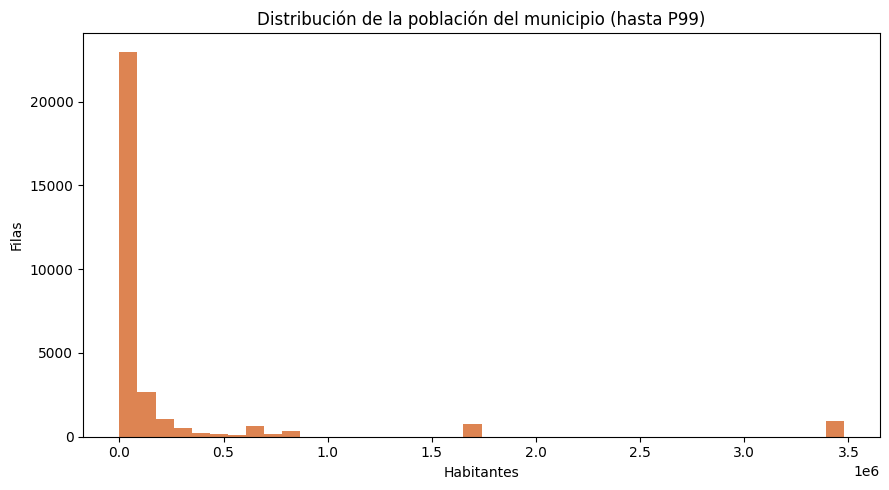

Mediana de 15,567 habitantes: la mayoría de carreras cruzadas ocurren en municipios pequeños o medianos, con una cola de grandes ciudades que estira mucho la media (219,383) por encima de la mediana.


In [19]:
con_poblacion = todas["poblacion_total"].dropna()
con_poblacion.clip(upper=con_poblacion.quantile(0.99)).plot(kind="hist", bins=40, color="#DD8452")
plt.title("Distribución de la población del municipio (hasta P99)")
plt.xlabel("Habitantes")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

print(f"Mediana de {con_poblacion.median():,.0f} habitantes: la mayoría de carreras cruzadas ocurren en "
      "municipios pequeños o medianos, con una cola de grandes ciudades que estira mucho la media "
      f"({con_poblacion.mean():,.0f}) por encima de la mediana.")

## 2. Correlación entre variables

Para poder meter en una misma matriz de correlación los campos categóricos (`publico`, `tipo_modalidad`, `fuente`, `dia_semana`, `estacion`) hace falta pasarlos a números. En vez de numerarlos sin criterio, usamos algo con sentido: para `dia_semana` y `estacion` el propio calendario ya da un orden natural (Lunes→Domingo, Invierno→Otoño); para `publico`, `tipo_modalidad` y `fuente` no hay un orden evidente, así que codificamos cada categoría según la mediana de `total_finishers` que le corresponde (a más mediana, código más bajo). Así el número refleja "carreras grandes vs. carreras pequeñas" en vez de ser arbitrario.

In [20]:
import numpy as np

DIA_A_NUM = {"Lunes": 1, "Martes": 2, "Miércoles": 3, "Jueves": 4, "Viernes": 5, "Sábado": 6, "Domingo": 7}
ESTACION_A_NUM = {"Invierno": 1, "Primavera": 2, "Verano": 3, "Otoño": 4}

def codificar_por_tamano(columna):
    """Numera las categorías de una columna según la mediana de total_finishers, de mayor a menor."""
    orden = todas.groupby(columna)["total_finishers"].median().sort_values(ascending=False)
    return todas[columna].map({cat: i + 1 for i, cat in enumerate(orden.index)})

num = pd.DataFrame({
    "distancia": todas["distancia"].replace(0, np.nan),
    "anyo": todas["anyo"],
    "es_finde": todas["es_finde"].astype(int),
    "dia_semana_num": todas["dia_semana"].map(DIA_A_NUM),
    "estacion_num": todas["estacion"].map(ESTACION_A_NUM),
    "publico_cod": codificar_por_tamano("publico"),
    "tipo_modalidad_cod": codificar_por_tamano("tipo_modalidad"),
    "fuente_cod": codificar_por_tamano("fuente"),
    "poblacion_total": todas["poblacion_total"],
    "poblacion_hombres": todas["poblacion_hombres"],
    "poblacion_mujeres": todas["poblacion_mujeres"],
    "finisher_d": todas["finisher_d"],
    "finisher_h": todas["finisher_h"],
    "total_finishers": todas["total_finishers"],
})

corr = num.corr(numeric_only=True)
corr.round(2)

,distancia,anyo,es_finde,dia_semana_num,estacion_num,publico_cod,tipo_modalidad_cod,fuente_cod,poblacion_total,poblacion_hombres,poblacion_mujeres,finisher_d,finisher_h,total_finishers
distancia,1.00,-0.00,0.04,0.01,0.03,-0.18,0.14,-0.17,-0.06,-0.06,-0.06,-0.03,0.07,0.02
anyo,-0.00,1.00,-0.01,-0.00,-0.08,0.08,-0.06,0.01,-0.00,-0.00,-0.00,-0.02,-0.06,-0.05
es_finde,0.04,-0.01,1.00,0.80,0.10,0.01,-0.03,0.05,-0.03,-0.03,-0.03,0.01,-0.00,0.00
dia_semana_num,0.01,-0.00,0.80,1.00,0.08,0.01,-0.06,0.04,0.02,0.02,0.02,0.02,0.01,0.02
estacion_num,0.03,-0.08,0.10,0.08,1.00,-0.04,0.01,0.00,0.01,0.01,0.01,0.00,-0.05,-0.03
publico_cod,-0.18,0.08,0.01,0.01,-0.04,1.00,0.01,0.29,0.05,0.05,0.05,-0.06,-0.14,-0.12
tipo_modalidad_cod,0.14,-0.06,-0.03,-0.06,0.01,0.01,1.00,-0.13,-0.07,-0.07,-0.07,-0.06,-0.06,-0.07
fuente_cod,-0.17,0.01,0.05,0.04,0.00,0.29,-0.13,1.00,0.09,0.09,0.09,-0.03,-0.07,-0.06
poblacion_total,-0.06,-0.00,-0.03,0.02,0.01,0.05,-0.07,0.09,1.00,1.00,1.00,0.13,0.15,0.17
poblacion_hombres,-0.06,-0.00,-0.03,0.02,0.01,0.05,-0.07,0.09,1.00,1.00,1.00,0.13,0.15,0.17


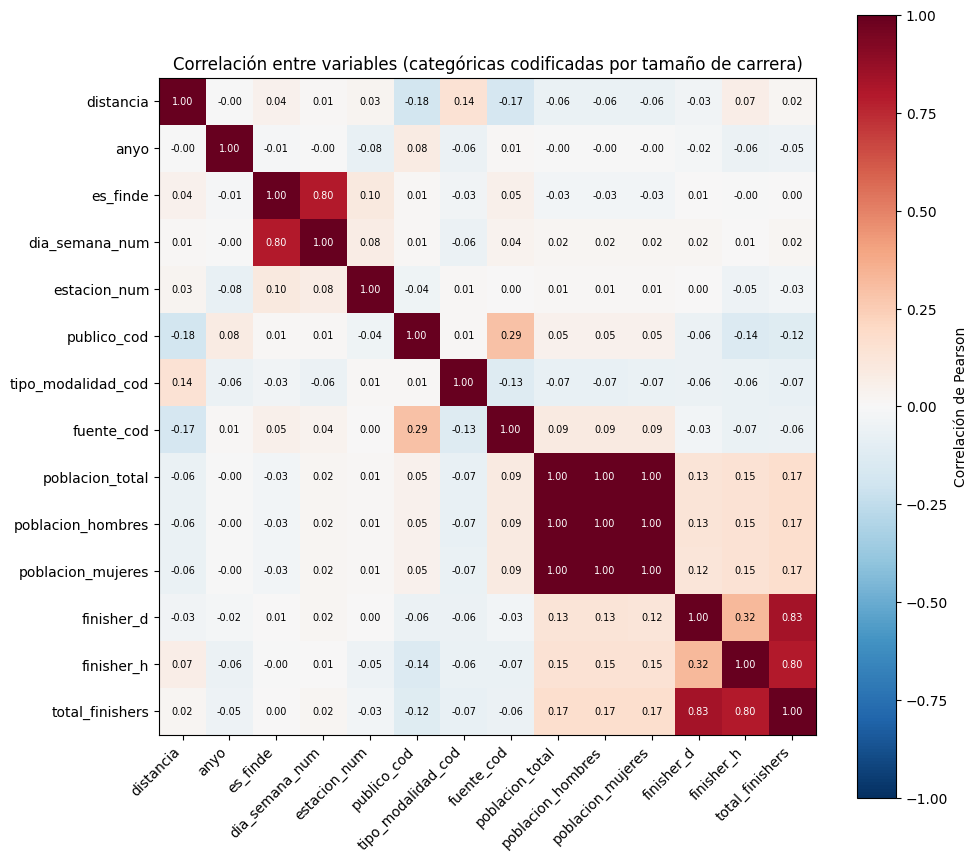

In [21]:
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if abs(corr.values[i, j]) > 0.6 else "black")
ax.set_title("Correlación entre variables (categóricas codificadas por tamaño de carrera)")
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
plt.tight_layout()
plt.show()

In [22]:
pares = corr.mask(np.eye(len(corr), dtype=bool))
pares_target = pares[["finisher_d", "finisher_h"]].drop(index=["finisher_d", "finisher_h", "total_finishers"]).abs()
ranking_target = pares_target.max(axis=1).sort_values(ascending=False)
print("Variables más correlacionadas con los objetivos (valor absoluto):")
print(ranking_target.round(2))
print()
print(f"Ninguna variable por separado pasa de {ranking_target.iloc[0]:.2f}: el tamaño de una carrera no se explica "
      "bien por una sola columna, hace falta combinarlas (que es justo lo que hará el árbol). Las que más pesan "
      "son la población del municipio y publico_cod; distancia, día de la semana y estación aportan poco por sí "
      f"solos. Por otro lado, es_finde y dia_semana_num van casi calcadas entre sí "
      f"({corr.loc['es_finde', 'dia_semana_num']:.2f} de correlación), lógico porque una se deriva de la otra, "
      "así que no tiene mucho sentido meter las dos en el mismo modelo.")

Variables más correlacionadas con los objetivos (valor absoluto):
poblacion_hombres     0.15
poblacion_total       0.15
poblacion_mujeres     0.15
publico_cod           0.14
distancia             0.07
fuente_cod            0.07
tipo_modalidad_cod    0.06
anyo                  0.06
estacion_num          0.05
dia_semana_num        0.02
es_finde              0.01
dtype: float64

Ninguna variable por separado pasa de 0.15: el tamaño de una carrera no se explica bien por una sola columna, hace falta combinarlas (que es justo lo que hará el árbol). Las que más pesan son la población del municipio y publico_cod; distancia, día de la semana y estación aportan poco por sí solos. Por otro lado, es_finde y dia_semana_num van casi calcadas entre sí (0.80 de correlación), lógico porque una se deriva de la otra, así que no tiene mucho sentido meter las dos en el mismo modelo.


## 3. Análisis bivariable frente a los objetivos

Aquí cruzamos cada variable con `finisher_d` y `finisher_h` a la vez, en vez de mirar solo el total, para ver si además del tamaño de la carrera cambia el reparto entre hombres y mujeres.

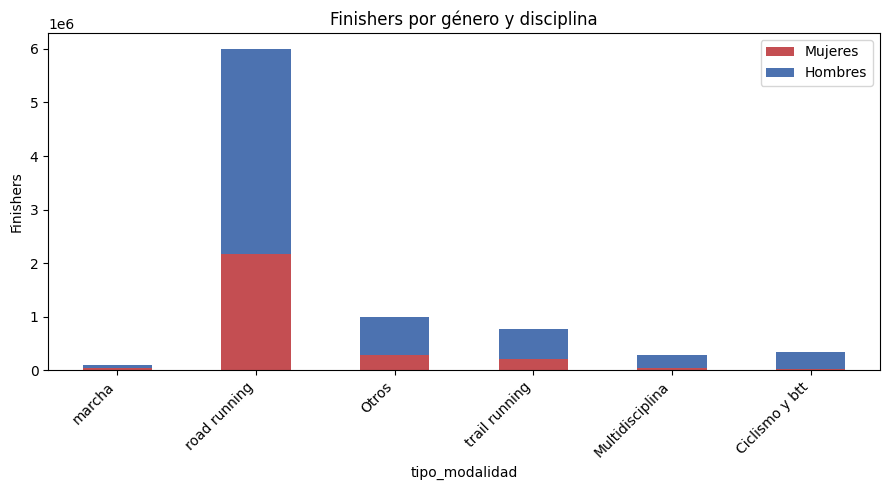

marcha es la disciplina más paritaria (38% mujeres) y Ciclismo y btt la menos (6% mujeres). En ninguna disciplina se llega al 50%, la participación femenina siempre queda por debajo de la masculina.


,finisher_d,finisher_h,pct_mujeres
tipo_modalidad,,,
marcha,41074.0,67609.0,37.792479
road running,2169818.0,3829193.0,36.169595
Otros,280947.0,718983.0,28.096667
trail running,203908.0,572251.0,26.271421
Multidisciplina,40416.0,238282.0,14.501719
Ciclismo y btt,19972.0,331342.0,5.684943


In [23]:
por_tipo = todas.groupby("tipo_modalidad")[["finisher_d", "finisher_h"]].sum()
por_tipo["pct_mujeres"] = 100 * por_tipo["finisher_d"] / (por_tipo["finisher_d"] + por_tipo["finisher_h"])
por_tipo = por_tipo.sort_values("pct_mujeres", ascending=False)

por_tipo[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y disciplina")
plt.ylabel("Finishers")
plt.xticks(rotation=45, ha="right")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(f"{por_tipo['pct_mujeres'].idxmax()} es la disciplina más paritaria ({por_tipo['pct_mujeres'].max():.0f}% mujeres) "
      f"y {por_tipo['pct_mujeres'].idxmin()} la menos ({por_tipo['pct_mujeres'].min():.0f}% mujeres). "
      "En ninguna disciplina se llega al 50%, la participación femenina siempre queda por debajo de la masculina.")
por_tipo

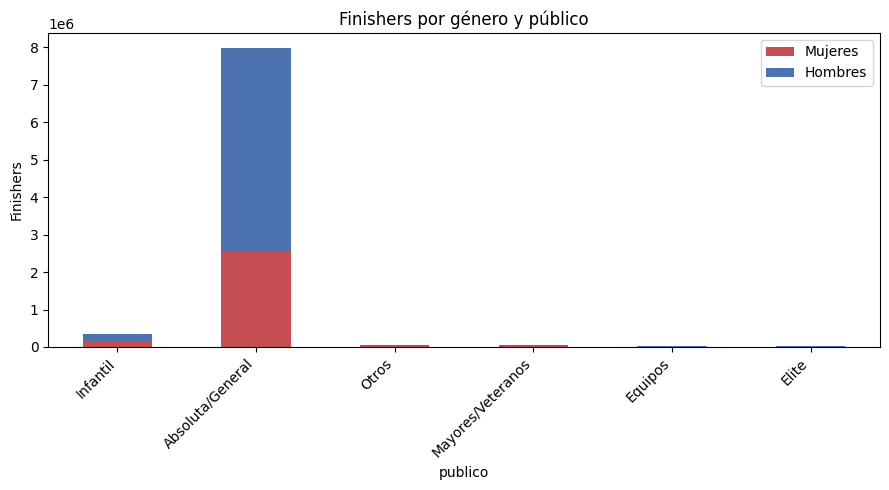

El reparto por género cambia bastante según el público: Infantil tiene el 43% de mujeres, mientras que en Elite apenas llega al 21%. No es solo que unas categorías tengan carreras más grandes que otras, también varía quién participa en ellas.


,finisher_d,finisher_h,pct_mujeres
publico,,,
Infantil,152388.0,201822.0,43.021936
Absoluta/General,2553435.0,5435169.0,31.963469
Otros,19224.0,41932.0,31.434365
Mayores/Veteranos,18139.0,41131.0,30.604016
Equipos,10317.0,27811.0,27.058854
Elite,2632.0,9795.0,21.179689


In [24]:
por_publico = todas.groupby("publico")[["finisher_d", "finisher_h"]].sum()
por_publico["pct_mujeres"] = 100 * por_publico["finisher_d"] / (por_publico["finisher_d"] + por_publico["finisher_h"])
por_publico = por_publico.sort_values("pct_mujeres", ascending=False)

por_publico[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y público")
plt.ylabel("Finishers")
plt.xticks(rotation=45, ha="right")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(f"El reparto por género cambia bastante según el público: {por_publico['pct_mujeres'].idxmax()} tiene el "
      f"{por_publico['pct_mujeres'].max():.0f}% de mujeres, mientras que en {por_publico['pct_mujeres'].idxmin()} "
      f"apenas llega al {por_publico['pct_mujeres'].min():.0f}%. No es solo que unas categorías tengan carreras "
      "más grandes que otras, también varía quién participa en ellas.")
por_publico

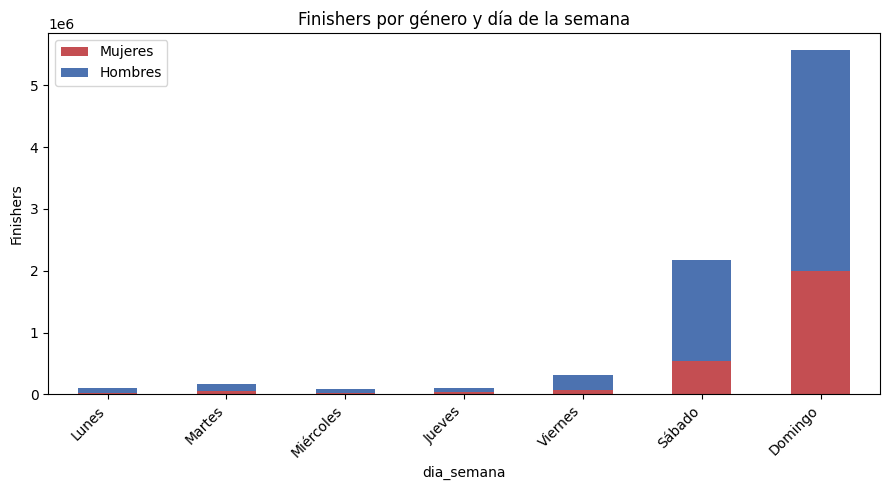

            finisher_d  finisher_h  pct_mujeres
dia_semana                                     
Lunes          26326.0     74769.0    26.040853
Martes         51433.0    109361.0    31.986890
Miércoles      28231.0     64329.0    30.500216
Jueves         35396.0     68572.0    34.045091
Viernes        74559.0    232104.0    24.313008
Sábado        541939.0   1638842.0    24.850684
Domingo      1998251.0   3569683.0    35.888554

El % de mujeres se mueve entre 24% y 36% según el día, sin una tendencia clara fin de semana vs. entre semana; el volumen total sí que es muchísimo mayor en sábado y domingo, como ya se vio en el univariable.


In [25]:
ORDEN_DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
por_dia_gen = todas.groupby("dia_semana")[["finisher_d", "finisher_h"]].sum().reindex(ORDEN_DIAS)
por_dia_gen["pct_mujeres"] = 100 * por_dia_gen["finisher_d"] / (por_dia_gen["finisher_d"] + por_dia_gen["finisher_h"])

fig, ax1 = plt.subplots(figsize=(9, 5))
por_dia_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, ax=ax1, color=["#C44E52", "#4C72B0"])
ax1.set_title("Finishers por género y día de la semana")
ax1.set_ylabel("Finishers")
ax1.legend(["Mujeres", "Hombres"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(por_dia_gen)
print()
print(f"El % de mujeres se mueve entre {por_dia_gen['pct_mujeres'].min():.0f}% y {por_dia_gen['pct_mujeres'].max():.0f}% "
      "según el día, sin una tendencia clara fin de semana vs. entre semana; el volumen total sí que es "
      "muchísimo mayor en sábado y domingo, como ya se vio en el univariable.")

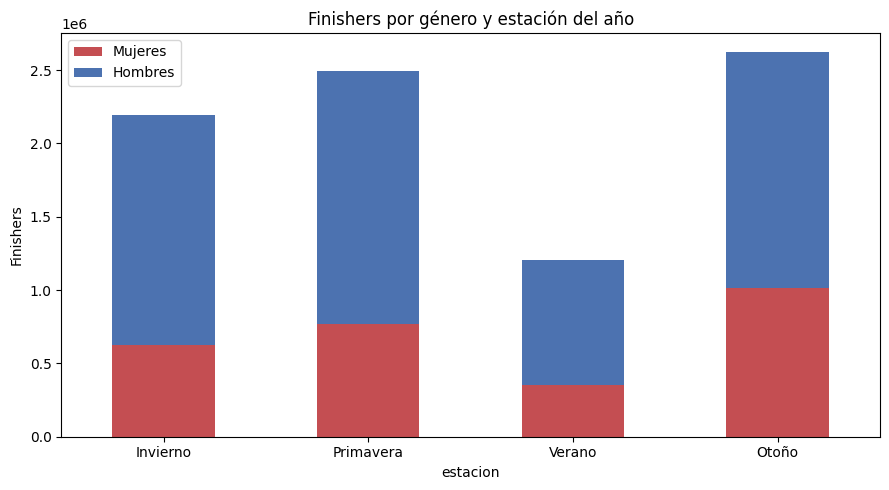

           finisher_d  finisher_h  pct_mujeres
estacion                                      
Invierno     627099.0   1564021.0    28.620021
Primavera    765586.0   1730256.0    30.674458
Verano       352555.0    851323.0    29.284944
Otoño       1010895.0   1612060.0    38.540310

Otoño concentra el mayor volumen de finishers, coherente con el calendario de carreras que ya vimos en el univariable (menos carreras no significa necesariamente menos participación total, si las que hay son más grandes).


In [26]:
ORDEN_ESTACIONES = ["Invierno", "Primavera", "Verano", "Otoño"]
por_estacion_gen = todas.groupby("estacion")[["finisher_d", "finisher_h"]].sum().reindex(ORDEN_ESTACIONES)
por_estacion_gen["pct_mujeres"] = 100 * por_estacion_gen["finisher_d"] / (por_estacion_gen["finisher_d"] + por_estacion_gen["finisher_h"])

por_estacion_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y estación del año")
plt.ylabel("Finishers")
plt.xticks(rotation=0)
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(por_estacion_gen)
print()
print(f"{por_estacion_gen['finisher_d'].add(por_estacion_gen['finisher_h']).idxmax()} concentra el mayor volumen "
      "de finishers, coherente con el calendario de carreras que ya vimos en el univariable (menos carreras "
      "no significa necesariamente menos participación total, si las que hay son más grandes).")

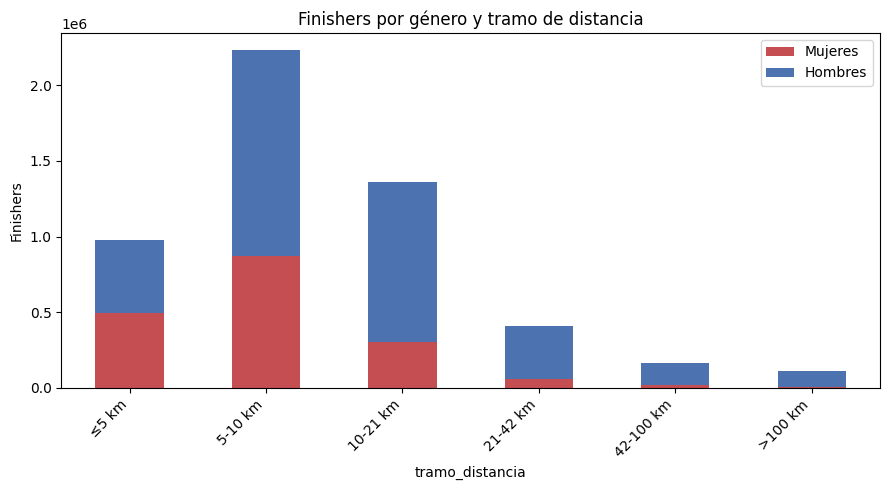

                 finisher_d  finisher_h  pct_mujeres
tramo_distancia                                     
≤5 km              492402.0    485716.0    50.341779
5-10 km            871992.0   1362867.0    39.017764
10-21 km           302877.0   1056049.0    22.287969
21-42 km            61595.0    347643.0    15.051144
42-100 km           18306.0    146174.0    11.129621
>100 km              6837.0    104914.0     6.118066

El % de mujeres cae de forma bastante consistente a medida que crece la distancia: 50% en el tramo más corto frente a 6% en el más largo. En las distancias de ultra la brecha de género es mucho más marcada que en las carreras populares cortas.


In [27]:
con_distancia_gen = todas[todas["distancia"] != 0].copy()
bins = [0, 5, 10, 21.5, 42.5, 100, con_distancia_gen["distancia"].max() + 1]
etiquetas = ["≤5 km", "5-10 km", "10-21 km", "21-42 km", "42-100 km", ">100 km"]
con_distancia_gen["tramo_distancia"] = pd.cut(con_distancia_gen["distancia"], bins=bins, labels=etiquetas)

por_distancia_gen = con_distancia_gen.groupby("tramo_distancia", observed=True)[["finisher_d", "finisher_h"]].sum()
por_distancia_gen["pct_mujeres"] = 100 * por_distancia_gen["finisher_d"] / (por_distancia_gen["finisher_d"] + por_distancia_gen["finisher_h"])

por_distancia_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y tramo de distancia")
plt.ylabel("Finishers")
plt.xticks(rotation=45, ha="right")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(por_distancia_gen)
print()
print(f"El % de mujeres cae de forma bastante consistente a medida que crece la distancia: "
      f"{por_distancia_gen['pct_mujeres'].iloc[0]:.0f}% en el tramo más corto frente a "
      f"{por_distancia_gen['pct_mujeres'].iloc[-1]:.0f}% en el más largo. En las distancias de ultra "
      "la brecha de género es mucho más marcada que en las carreras populares cortas.")

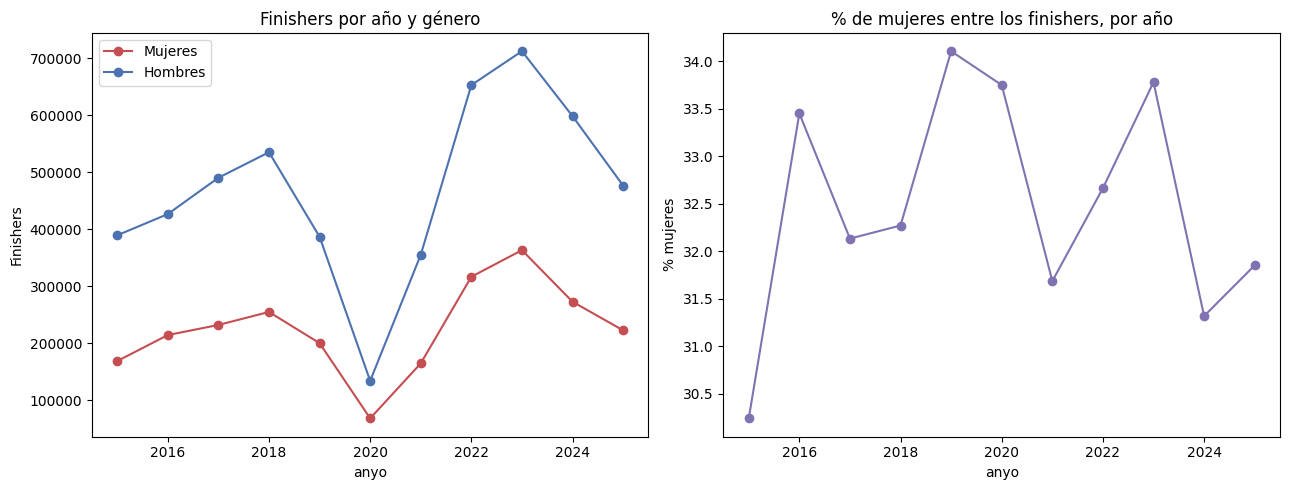

Entre 2015 y 2025 los finishers hombres se multiplican por 1.2 y los finishers mujeres por 1.3: la participación femenina crece algo más rápido en términos relativos, aunque sigue partiendo de una base mucho más baja, así que el % de mujeres solo sube de 30% a 32%.


In [28]:
por_anyo_gen = (
    todas[(todas["anyo"] >= 2015) & (todas["anyo"] <= 2025)]
    .groupby("anyo")[["finisher_d", "finisher_h"]].sum()
)
por_anyo_gen["pct_mujeres"] = 100 * por_anyo_gen["finisher_d"] / (por_anyo_gen["finisher_d"] + por_anyo_gen["finisher_h"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
por_anyo_gen[["finisher_d", "finisher_h"]].plot(marker="o", ax=ax1, color=["#C44E52", "#4C72B0"])
ax1.set_title("Finishers por año y género")
ax1.set_ylabel("Finishers")
ax1.legend(["Mujeres", "Hombres"])

por_anyo_gen["pct_mujeres"].plot(marker="o", ax=ax2, color="#8172B2")
ax2.set_title("% de mujeres entre los finishers, por año")
ax2.set_ylabel("% mujeres")

plt.tight_layout()
plt.show()

crecim_d = por_anyo_gen["finisher_d"].iloc[-1] / por_anyo_gen["finisher_d"].iloc[0]
crecim_h = por_anyo_gen["finisher_h"].iloc[-1] / por_anyo_gen["finisher_h"].iloc[0]
print(f"Entre {por_anyo_gen.index[0]} y {por_anyo_gen.index[-1]} los finishers hombres se multiplican por "
      f"{crecim_h:.1f} y los finishers mujeres por {crecim_d:.1f}: la participación femenina crece algo más "
      "rápido en términos relativos, aunque sigue partiendo de una base mucho más baja, así que el % de "
      f"mujeres solo sube de {por_anyo_gen['pct_mujeres'].iloc[0]:.0f}% a {por_anyo_gen['pct_mujeres'].iloc[-1]:.0f}%.")

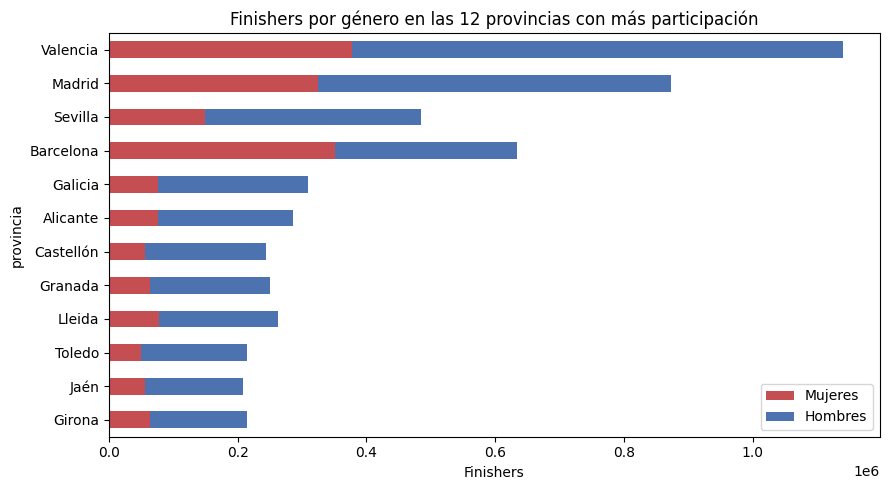

           finisher_d  finisher_h  pct_mujeres
provincia                                     
Valencia     377470.0    763460.0         33.1
Madrid       324719.0    549208.0         37.2
Barcelona    351666.0    281941.0         55.5
Sevilla      150061.0    334981.0         30.9
Galicia       75849.0    232725.0         24.6
Alicante      76491.0    209949.0         26.7
Lleida        77118.0    186146.0         29.3
Granada       63192.0    187420.0         25.2
Castellón     56390.0    188372.0         23.0
Girona        63442.0    150997.0         29.6
Toledo        50322.0    163882.0         23.5
Jaén          56143.0    152325.0         26.9

Dentro del top de provincias por volumen, el % de mujeres va de 23% a 56%: tener mucha participación total no implica tener una participación más equilibrada por género.


In [29]:
top_provincias_gen = (
    todas.groupby("provincia")[["finisher_d", "finisher_h"]].sum()
    .assign(total=lambda d: d["finisher_d"] + d["finisher_h"])
    .sort_values("total", ascending=False)
    .head(12)
)
top_provincias_gen["pct_mujeres"] = 100 * top_provincias_gen["finisher_d"] / top_provincias_gen["total"]

top_provincias_gen[["finisher_d", "finisher_h"]].sort_values("finisher_h").plot(
    kind="barh", stacked=True, color=["#C44E52", "#4C72B0"]
)
plt.title("Finishers por género en las 12 provincias con más participación")
plt.xlabel("Finishers")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(top_provincias_gen[["finisher_d", "finisher_h", "pct_mujeres"]].round(1))
print()
print(f"Dentro del top de provincias por volumen, el % de mujeres va de {top_provincias_gen['pct_mujeres'].min():.0f}% "
      f"a {top_provincias_gen['pct_mujeres'].max():.0f}%: tener mucha participación total no implica tener "
      "una participación más equilibrada por género.")

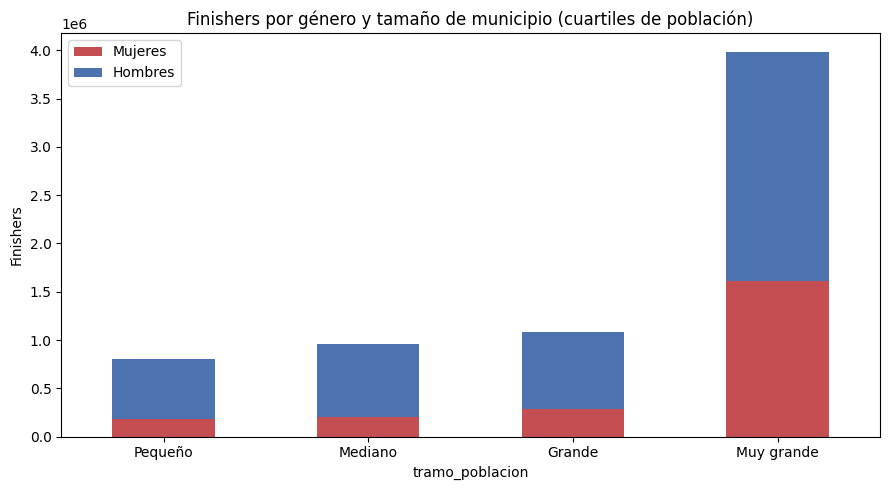

                 finisher_d  finisher_h  pct_mujeres
tramo_poblacion                                     
Pequeño            183113.0    623982.0    22.687912
Mediano            207199.0    755899.0    21.513802
Grande             290187.0    795817.0    26.720620
Muy grande        1611981.0   2370601.0    40.475777

El % de mujeres pasa de 23% en los municipios más pequeños a 40% en los más grandes: las ciudades grandes tienen una participación algo más equilibrada que los pueblos, aunque la diferencia no es enorme. Recordar que esto solo cubre el ~60% de filas donde el cruce con el INE ha funcionado.


In [30]:
con_poblacion_gen = todas[todas["poblacion_total"].notna()].copy()
con_poblacion_gen["tramo_poblacion"] = pd.qcut(
    con_poblacion_gen["poblacion_total"], q=4, labels=["Pequeño", "Mediano", "Grande", "Muy grande"]
)

por_poblacion_gen = con_poblacion_gen.groupby("tramo_poblacion", observed=True)[["finisher_d", "finisher_h"]].sum()
por_poblacion_gen["pct_mujeres"] = 100 * por_poblacion_gen["finisher_d"] / (por_poblacion_gen["finisher_d"] + por_poblacion_gen["finisher_h"])

por_poblacion_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y tamaño de municipio (cuartiles de población)")
plt.ylabel("Finishers")
plt.xticks(rotation=0)
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(por_poblacion_gen)
print()
print(f"El % de mujeres pasa de {por_poblacion_gen['pct_mujeres'].iloc[0]:.0f}% en los municipios más pequeños a "
      f"{por_poblacion_gen['pct_mujeres'].iloc[-1]:.0f}% en los más grandes: las ciudades grandes tienen una "
      "participación algo más equilibrada que los pueblos, aunque la diferencia no es enorme. Recordar que "
      "esto solo cubre el ~60% de filas donde el cruce con el INE ha funcionado.")

## 4. Histórico de la misma carrera, año a año

Todo lo anterior mira cada fila como si fuera independiente, pero muchas carreras se repiten año tras año con el mismo formato — y el tamaño de la edición anterior es, en principio, el mejor indicio del tamaño de la siguiente. Para comprobarlo hace falta identificar cuándo dos filas de años distintos son "la misma carrera": quitamos del nombre el ordinal de la edición (I, II, 1ª, XXIII...) y el año suelto, y agrupamos por ese nombre base dentro de cada fuente.

In [31]:
def _normalizar_base(nombre):
    if pd.isna(nombre):
        return None
    t = unicodedata.normalize("NFKD", str(nombre)).encode("ascii", "ignore").decode("ascii").upper()
    t = re.sub(r"[^A-Z0-9]+", " ", t)
    t = re.sub(r"^\s*(?:[IVXLC]{1,6}|\d{1,3}(?:A|O|ER|ERA)?)\b\s*", "", t)  # ordinal inicial
    t = re.sub(r"\b(19|20)\d{2}\b", "", t)  # año suelto
    return re.sub(r"\s{2,}", " ", t).strip()

todas["nombre_base"] = todas["nombre_carrera"].apply(_normalizar_base)

ediciones_por_carrera = todas.groupby(["fuente", "nombre_base"])["anyo"].nunique()
print(f"Carreras (fuente + nombre base) con datos en 2 años o más: "
      f"{(ediciones_por_carrera > 1).sum()} de {len(ediciones_por_carrera)} "
      f"({100*(ediciones_por_carrera > 1).mean():.0f}%)")

Carreras (fuente + nombre base) con datos en 2 años o más: 3249 de 10830 (30%)


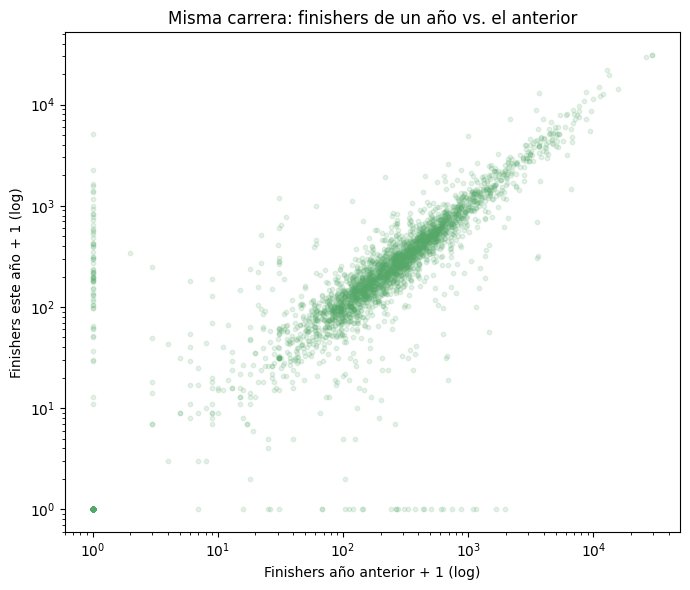

Pares de ediciones consecutivas disponibles: 5956
Correlación finishers(año) vs. finishers(año-1), misma carrera: 0.90

Es, con diferencia, la señal más fuerte de todo el análisis (todo lo demás en el heatmap se quedaba por debajo de 0.16): saber cuánta gente corrió la edición anterior de una carrera predice muchísimo mejor la siguiente que cualquier combinación de tipo_modalidad/publico/distancia/población. Para el árbol de finishers, el histórico propio de cada carrera (cuando existe) debería ser el predictor principal, y el resto de variables quedarían para las carreras nuevas sin historial.


In [32]:
# Para cada carrera, comparamos el total de finishers de un año con el del
# año inmediatamente anterior (solo años consecutivos, para no mezclar
# ediciones con un hueco de por medio).
por_anyo = todas.groupby(["fuente", "nombre_base", "anyo"])["total_finishers"].sum().reset_index()
por_anyo = por_anyo.sort_values(["fuente", "nombre_base", "anyo"])
por_anyo["anyo_anterior"] = por_anyo.groupby(["fuente", "nombre_base"])["anyo"].shift(1)
por_anyo["finishers_anyo_anterior"] = por_anyo.groupby(["fuente", "nombre_base"])["total_finishers"].shift(1)

consecutivos = por_anyo[por_anyo["anyo"] - por_anyo["anyo_anterior"] == 1].dropna(subset=["finishers_anyo_anterior"])
corr_historico = consecutivos["total_finishers"].corr(consecutivos["finishers_anyo_anterior"])

muestra = consecutivos.sample(min(3000, len(consecutivos)), random_state=0)
plt.figure(figsize=(7, 6))
plt.scatter(muestra["finishers_anyo_anterior"] + 1, muestra["total_finishers"] + 1, alpha=0.15, s=10, color="#55A868")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Finishers año anterior + 1 (log)")
plt.ylabel("Finishers este año + 1 (log)")
plt.title("Misma carrera: finishers de un año vs. el anterior")
plt.tight_layout()
plt.show()

print(f"Pares de ediciones consecutivas disponibles: {len(consecutivos)}")
print(f"Correlación finishers(año) vs. finishers(año-1), misma carrera: {corr_historico:.2f}")
print()
print("Es, con diferencia, la señal más fuerte de todo el análisis (todo lo demás en el heatmap se "
      "quedaba por debajo de 0.16): saber cuánta gente corrió la edición anterior de una carrera predice "
      "muchísimo mejor la siguiente que cualquier combinación de tipo_modalidad/publico/distancia/población. "
      "Para el árbol de finishers, el histórico propio de cada carrera (cuando existe) debería ser el "
      "predictor principal, y el resto de variables quedarían para las carreras nuevas sin historial.")

## Notas finales

- Las distancias por encima de 100 km (272 filas) casi todas son reales: marchas cicloturistas/gran fondo (Mallorca 312, Marcha Ciclodeportiva Guad al Xenil...) y ultra-trails ("100 Millas Sierras del Bandolero") de verdad llegan a esas distancias. Solo un puñado son casos raros de verdad: un par de "retos" acumulados a lo largo de semanas ("GR7 por la Epilepsia", 934 km, no es una carrera de un día) y "EPIC RACE PONTEVEDRA" con 300/200 km que no cuadra con lo que suele ser esa marca (carreras de obstáculos cortas) — probablemente un fallo de extracción puntual, sin investigar más por ahora.
- `comarca` tiene cobertura muy desigual entre fuentes (buena en Catalunya/Galicia, floja en el resto), mejor no usarla a nivel global sin filtrar antes por región.
- `distancia == 0` es un centinela de "no detectado", no una distancia real; para cualquier cálculo con distancia hay que filtrarlo antes.
- `cruzandolameta` todavía no incluye los eventos en PDF, quedan pendientes de una futura ampliación del scraper.
- El cruce con el INE cubre alrededor del 73% de las filas; el resto son sobre todo fuentes donde `provincia` guarda la comunidad autónoma en vez de la provincia.
- La tabla queda guardada en `DF_TODAS.csv`, pero solo con las 12 columnas comunes: las columnas derivadas (`anyo`, `estacion`, `total_finishers`, `es_finde`, `nombre_base`, la población del INE) hay que volver a calcularlas si se recarga el CSV desde cero.
- Para preparar los datos de cara al árbol de finishers, ver `Limpieza_outliers.ipynb`: convierte el centinela de `distancia` en `NaN` y guarda `DF_TODAS_MODELO.csv`.
- De cara al modelo: ninguna variable por separado correlaciona fuerte con `finisher_d`/`finisher_h` (todas por debajo de 0.16), así que el árbol necesitará combinarlas; `publico` y la población del municipio son las que más pesan de forma aislada, y `distancia` apenas aporta nada por sí sola. `es_finde` y `dia_semana` van casi calcadas entre sí, así que no hace falta meter las dos en el modelo. Hay una tendencia temporal a lo largo de los años que probablemente merece entrar como predictor si el modelo se va a usar para carreras futuras.
- **Para el split train/test del futuro modelo: nada de partir filas al azar.** La misma carrera en años consecutivos está correlacionada al 0.90 en finishers (ver sección 4), así que un split aleatorio dejaría la edición 2022 de una carrera en train y la 2023 en test — el modelo parecería mucho mejor de lo que realmente es porque estaría casi copiando la respuesta. Hay que partir por carrera (`nombre_base`) o por corte temporal (años), nunca por fila individual.